#  **Deep Neural Networks for Image Classification (Part I)**
#  **Multilayer Perceptron (MLP)**

*   We will create neural networks using Multilayer Perceptrons (MLPs) for classifying CIFAR10 images. We will follow the steps below:
   *  Load (train) CIFAR10 dataset (32x32 RGB images; 10 classes);
   *  Compute mean and standard deviation for data normalization;
   *  Load *normalized* (train and test) CIFAR10 dataset;
   *  Split train set into train and validation sets;
   *  Create iterators for train/test/val sets;
   *  Build the model based on MLP;
   *  Create train/validation/test phases;
   *  Test the model;
   *  Hyper-parameters fine-tuning;
   *  Data augmentation;
   *  Weights initialization.

	• Use the GPU to speed up the training time of you models (Runtime -> Change runtime type -> Hardware accelerator -> GPU).

	• We will use PyTorch. More details at https://pytorch.org/ - https://pytorch.org/tutorials/.  

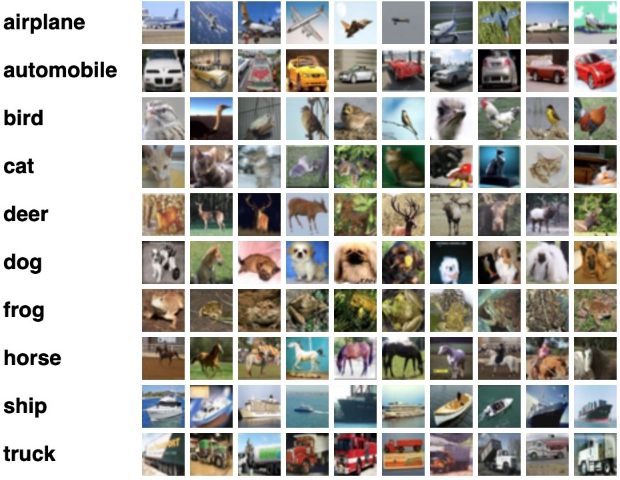

In [1]:
# Pytorch functions
import torch
# Neural network layers
import torch.nn as nn
import torch.nn.functional as F
# Optimizer
import torch.optim as optim
# Handling dataset
import torch.utils.data as data
# Torchvision library
import torchvision

import matplotlib.pyplot as plt
import random
import numpy as np
import copy
import time
import os
import cv2
# For results
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

###   Loading CIFAR-10 dataset

Set "USE_SEED" to False for your own experiments.

In [2]:
def set_seed(seed, use_gpu = True):
    """
    Set SEED for PyTorch reproducibility
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if use_gpu:
        torch.cuda.manual_seed_all(seed)
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

SEED = 44

USE_SEED = True

if USE_SEED:
    set_seed(SEED, torch.cuda.is_available())

In [3]:
# Load CIFAR10 dataset
# Available datasets at https://pytorch.org/vision/stable/datasets.html
ROOT = './data'
train_data = torchvision.datasets.CIFAR10(root=ROOT, train=True, download=True)

# You can also use the 'transform' argument to specify transformations to apply to the dataset
# e.g. 'train_data = torchvision.datasets.CIFAR10(root=ROOT, train=True, download=True, transform=...)'
# See the next steps for applying transformations to a dataset.

In [4]:
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

In [5]:
print("-------  DATASET  INFO  --------")
print(train_data)
print()
print(train_data.data.shape)

-------  DATASET  INFO  --------
Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./data
    Split: Train

(50000, 32, 32, 3)


In [6]:
# Each datapoint is a tuple (image, label)
print("------  DATAPOINT  INFO  ---------")
img = train_data[0][0]
label = train_data[0][1]
print(img) # N_CHANNELS, HEIGHT, WIDTH
print(label)

------  DATAPOINT  INFO  ---------
<PIL.Image.Image image mode=RGB size=32x32 at 0x787267664920>
6


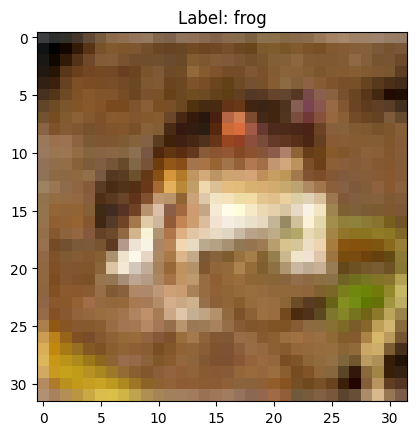

In [7]:
plt.imshow(img), plt.title("Label: " + classes[label])
plt.show()

###  Data normalization

In [8]:
# Print min and max rgb values for the 1st image
# You can access the images using the data attribute. The image is stored as a numpy array.
print(f'Image shape: {train_data.data[0].shape}\n')

min_RGB_values = train_data.data[0].min(axis=(0,1))
print(f"Minimum RGB values : {min_RGB_values}")
max_RGB_values = train_data.data[0].max(axis=(0,1))
print(f"Maximum RGB values : {max_RGB_values}")

Image shape: (32, 32, 3)

Minimum RGB values : [0 0 0]
Maximum RGB values : [255 253 235]


In [9]:
# Mean and std should be divided by 255 (maximum pixel value)
# because, after the ToTensor() transformation (see next step), images are normalized
# between 0 and 1.
train_mean = train_data.data.mean(axis=(0,1,2)) / 255
train_std = train_data.data.std(axis=(0,1,2)) / 255

print("-----  TRAIN NORMALIZATION VALUES  -----")
print(f"Mean: {train_mean}")
print(f"Standard Deviation: {train_std}")

-----  TRAIN NORMALIZATION VALUES  -----
Mean: [0.49139968 0.48215841 0.44653091]
Standard Deviation: [0.24703223 0.24348513 0.26158784]


In [10]:
# Compositions of transformations
# Instead of using PIL images, we will convert them to a Tensor
# which is the data type used by Pytorch.
train_transforms = torchvision.transforms.Compose([
                                                   torchvision.transforms.ToTensor(), # values are normalized between 0 and 1
                                                   torchvision.transforms.Normalize(train_mean, train_std)
])

test_transforms = torchvision.transforms.Compose([
                                                   torchvision.transforms.ToTensor(),
                                                   torchvision.transforms.Normalize(train_mean, train_std)
])

In [11]:
# Load data with transformations
train_data = torchvision.datasets.CIFAR10(root=ROOT,
                                        train=True,
                                        download=True,
                                        transform=train_transforms)

test_data = torchvision.datasets.CIFAR10(root=ROOT,
                                        train=False,
                                        download=True,
                                        transform=test_transforms)
print(train_data)
print(test_data)

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=[0.49139968 0.48215841 0.44653091], std=[0.24703223 0.24348513 0.26158784])
           )
Dataset CIFAR10
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=[0.49139968 0.48215841 0.44653091], std=[0.24703223 0.24348513 0.26158784])
           )


In [12]:
# Each train/test example ia a tuple (image, label)
# Images are now torch tensors and not numpy arrays (they are very similar)
print("------  DATAPOINT  INFO  ---------")

img = train_data[0][0]
label = train_data[0][1]
print(f"Image size: {img.size()}") # N_CHANNELS, HEIGHT, WIDTH
print(f"Label: {label}")

------  DATAPOINT  INFO  ---------
Image size: torch.Size([3, 32, 32])
Label: 6


In [13]:
# Let's see if the images are normalized
min_RGB_values = train_data[0][0].amin(dim=(1,2))
print(f"Minimum RGB values : {min_RGB_values}")
max_RGB_values = train_data[0][0].amax(dim=(1,2))
print(f"Maximum RGB values : {max_RGB_values}")

Minimum RGB values : tensor([-1.9892, -1.9802, -1.7070])
Maximum RGB values : tensor([2.0588, 2.0946, 1.8160])


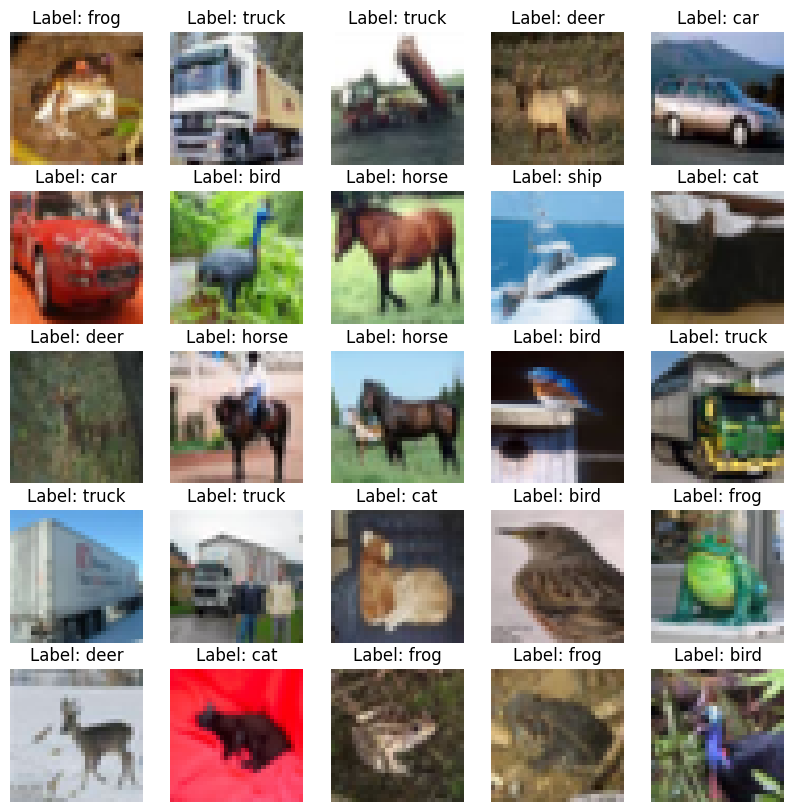

In [14]:
# Plot some training images
N_IMAGES = 25
plt.figure(figsize=(10, 10))
for i in range(N_IMAGES):
  img = train_data.data[i] # Unnormalized images
  label = train_data[i][1]
  plt.subplot(5,5,i+1), plt.imshow(img), plt.title(f"Label: {classes[label]}"), plt.axis('off')

### Train-Val Split

In [15]:
# Split train data into train and validation sets
# (10% of training set will be used as validation set)
num_train_examples = int(len(train_data) * 0.90)
num_valid_examples = len(train_data) - num_train_examples

print(f"Number of training examples: {num_train_examples}")
print(f"Number of validation examples: {num_valid_examples}")

Number of training examples: 45000
Number of validation examples: 5000


In [16]:
# Create 'Subset' objects
train_data, valid_data = data.random_split(train_data, [num_train_examples, num_valid_examples])

print(f"Number training examples: {len(train_data)}")
print(f"Number validation examples: {len(valid_data)}")

Number training examples: 45000
Number validation examples: 5000


In [17]:
# Apply test transformations to the validation set
valid_data = copy.deepcopy(valid_data) # If we change train transformations, this won't affect the validation set
valid_data.dataset.transform = test_transforms

In [18]:
# Create iterators
BATCH_SIZE = 128

train_iterator = torch.utils.data.DataLoader(train_data,
                                             shuffle=True,
                                             batch_size=BATCH_SIZE)

valid_iterator = torch.utils.data.DataLoader(valid_data,
                                             batch_size=BATCH_SIZE)

test_iterator = torch.utils.data.DataLoader(test_data,
                                            batch_size=BATCH_SIZE)

### How to create a linear layer?


A PyTorch layer can be defined as classes (using the 'nn' package) or as functions (using the 'functional' package). In the following, an example of using the 'nn' package for creating a linear layer.

In [19]:
# List of pytorch layers available at https://pytorch.org/docs/stable/nn.html
# Input
x = torch.randn((20,20))
# Linear Layer
linear_layer = nn.Linear(400,10) # (in_features, out_features)
# Activation function
relu = nn.ReLU()
# Output (apply linear layer and activation function to input values)
y = relu(linear_layer(x.view(20*20))) # view is basically a pytorch reshape

# Print output
print(y.shape)
print(y)

torch.Size([10])
tensor([0.0000, 0.2787, 0.9226, 0.1013, 0.0000, 0.0000, 0.0000, 0.0000, 0.4599,
        0.0000], grad_fn=<ReluBackward0>)


# **MLP : Creating Architecture**

Let's create a simple MLP network class with three layers with a sigmoid activation function for the hidden layer to classify CIFAR-10 images. The network must inherit from nn.Module and contain a forward method where the input is processed.

---

**Input Layer**: 32 * 32 * 3 = 3072 Units

**Hidden Layer**: 100 Units

**Output Layer**: 10 Units


In [20]:
# MLP architecture: [3072] -> [100] -> Sigmoid -> [10]

class MLP(nn.Module): # Inherit from PyTorch nn.Module
  def __init__(self, input_dim, output_dim):
    super().__init__()

    # Create two linear layers
    self.fc1 = nn.Linear(input_dim, 100)
    self.fc2 = nn.Linear(100, output_dim)
    self.sigmoid = nn.Sigmoid()

  def forward(self, x):
    batch_size = x.shape[0]
    # Flatten x
    x = x.view(batch_size, -1)
    x = self.fc1(x)
    x = self.sigmoid(x) # Apply sigmoid activation function ([ReLU, Tanh, Identity] are other alternatives)
    x = self.fc2(x)

    return x

*  Alternative network definition using a Sequential container. Use this container if input data is fed sequentially to each layer.

In [21]:
# # You can also use a sequential container if the data is passed sequentially to each contained layer.
# class MLP(nn.Module):
#   def __init__(self, input_dim, output_dim):
#     super().__init__()

#     self.linear_layers = nn.Sequential(  # Sequential container
#         nn.Linear(input_dim, 100),
#         nn.Sigmoid(),
#         nn.Linear(100, output_dim)
#     )


#   def forward(self, x):
#     batch_size = x.shape[0]
#     # Flatten x
#     x = x.view(batch_size, -1)
#     y = self.linear_layers(x)
#     return y

In [22]:
INPUT_DIM = 32*32*3 # 32x32x3 images
OUTPUT_DIM = 10 # 10 classes

In [23]:
# Inizialize the network
model = MLP(INPUT_DIM, OUTPUT_DIM)
print(model)

MLP(
  (fc1): Linear(in_features=3072, out_features=100, bias=True)
  (fc2): Linear(in_features=100, out_features=10, bias=True)
  (sigmoid): Sigmoid()
)


*   Let's plot the number of parameters of our network.

In [24]:
# List of parameters
for name, param in model.named_parameters():
  print(f"{name}, {param.shape}")

fc1.weight, torch.Size([100, 3072])
fc1.bias, torch.Size([100])
fc2.weight, torch.Size([10, 100])
fc2.bias, torch.Size([10])


*   Count the number of parameters

In [25]:
def count_parameters(model):
  return sum(p.numel() for p in model.parameters() if p.requires_grad) # Count only parameters that are backpropagated

In [26]:
print(f"The model has {count_parameters(model):,} trainable parameters.")

The model has 308,310 trainable parameters.


* Define Loss and Optimizer

In [27]:
# Loss
criterion = nn.CrossEntropyLoss() # Softmax + CrossEntropy

# Put model&criterion (loss) on GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

criterion = criterion.to(device)

In [28]:
# Optim
optimizer = optim.SGD(model.parameters(), lr=3e-3) # Adam optimizer is an alternative optimizer

model = model.to(device)

# **Training/Validation/Testing functions**

###   Compute accuracy

In [29]:
def calculate_accuracy(y_pred, y):
  '''
  Compute accuracy from ground-truth and predicted labels.

  Input
  ------
  y_pred: torch.Tensor [BATCH_SIZE, N_LABELS]
  y: torch.Tensor [BATCH_SIZE]

  Output
  ------
  accuracy: np.float
    Accuracy
  '''

  # Apply softmax (to convert values into probabilities)
  y_prob = F.softmax(y_pred, dim = -1)
  # Consider class with higher probability
  y_pred = y_pred.argmax(dim=1, keepdim = True)
  # Chech if prediction is correct
  correct = y_pred.eq(y.view_as(y_pred)).sum()
  # Compute accuracy (percentage)
  accuracy = correct.float()/y.shape[0]

  return accuracy

###  Training phase

In [30]:
def train(model, iterator, optimizer, criterion, device):
  epoch_loss = 0
  epoch_acc = 0

  # Apply train mode
  model.train()

  for (x,y) in iterator:
    x = x.to(device)
    y = y.to(device)

    # Set gradients to zero
    optimizer.zero_grad()

    # Make Predictions
    y_pred = model(x)

    # Compute loss
    loss = criterion(y_pred, y)

    # Compute accuracy
    acc = calculate_accuracy(y_pred, y)

    # Backprop
    loss.backward()

    # Apply optimizer
    optimizer.step()

    # Extract data from loss and accuracy
    epoch_loss += loss.item()
    epoch_acc += acc.item()

  return epoch_loss/len(iterator), epoch_acc/len(iterator)

### Validation/Testing phase

In [31]:
def evaluate(model, iterator, criterion, device):
  epoch_loss = 0
  epoch_acc = 0

  # Evaluation mode
  model.eval()

  # Do not compute gradients
  with torch.no_grad():

    for (x,y) in iterator:

      x = x.to(device)
      y = y.to(device)

      # Make Predictions
      y_pred = model(x)

      # Compute loss
      loss = criterion(y_pred, y)

      # Compute accuracy
      acc = calculate_accuracy(y_pred, y)

      # Extract data from loss and accuracy
      epoch_loss += loss.item()
      epoch_acc += acc.item()

  return epoch_loss/len(iterator), epoch_acc/len(iterator)

###  Model training

In [32]:
def model_training(n_epochs, model, train_iterator, valid_iterator, optimizer, criterion, device, model_name='best_model.pt'):

  # Initialize validation loss
  best_valid_loss = float('inf')

  # Save output losses, accs
  train_losses = []
  train_accs = []
  valid_losses = []
  valid_accs = []

  # Loop over epochs
  for epoch in range(n_epochs):
    start_time = time.time()

    # Train
    train_loss, train_acc = train(model, train_iterator, optimizer, criterion, device)
    # Validation
    valid_loss, valid_acc = evaluate(model, valid_iterator, criterion, device)
    # Save best model
    if valid_loss < best_valid_loss:
      best_valid_loss = valid_loss
      # Save model
      torch.save(model.state_dict(), model_name)
    end_time = time.time()

    print(f"\nEpoch: {epoch+1}/{n_epochs} -- Epoch Time: {end_time-start_time:.2f} s")
    print("---------------------------------")
    print(f"Train -- Loss: {train_loss:.3f}, Acc: {train_acc * 100:.2f}%")
    print(f"Val -- Loss: {valid_loss:.3f}, Acc: {valid_acc * 100:.2f}%")

    # Save
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    valid_losses.append(valid_loss)
    valid_accs.append(valid_acc)

  return train_losses, train_accs, valid_losses, valid_accs

In [ ]:
# Train a basic model?!?!? nah bro
N_EPOCHS=1
#train_losses, train_accs, valid_losses, valid_accs = model_training(N_EPOCHS,model,train_iterator,valid_iterator,optimizer,criterion,device,'mlp.pt')


Epoch: 1/1 -- Epoch Time: 10.77 s
---------------------------------
Train -- Loss: 2.194, Acc: 20.97%
Val -- Loss: 2.117, Acc: 25.72%


In [34]:
def plot_results(n_epochs, train_losses, train_accs, valid_losses, valid_accs):
  N_EPOCHS = n_epochs
  # Plot results
  plt.figure(figsize=(20, 6))
  _ = plt.subplot(1,2,1)
  plt.plot(np.arange(N_EPOCHS)+1, train_losses, linewidth=3)
  plt.plot(np.arange(N_EPOCHS)+1, valid_losses, linewidth=3)
  _ = plt.legend(['Train', 'Validation'])
  plt.grid('on'), plt.xlabel('Epoch'), plt.ylabel('Loss')

  _ = plt.subplot(1,2,2)
  plt.plot(np.arange(N_EPOCHS)+1, train_accs, linewidth=3)
  plt.plot(np.arange(N_EPOCHS)+1, valid_accs, linewidth=3)
  _ = plt.legend(['Train', 'Validation'])
  plt.grid('on'), plt.xlabel('Epoch'), plt.ylabel('Accuracy')

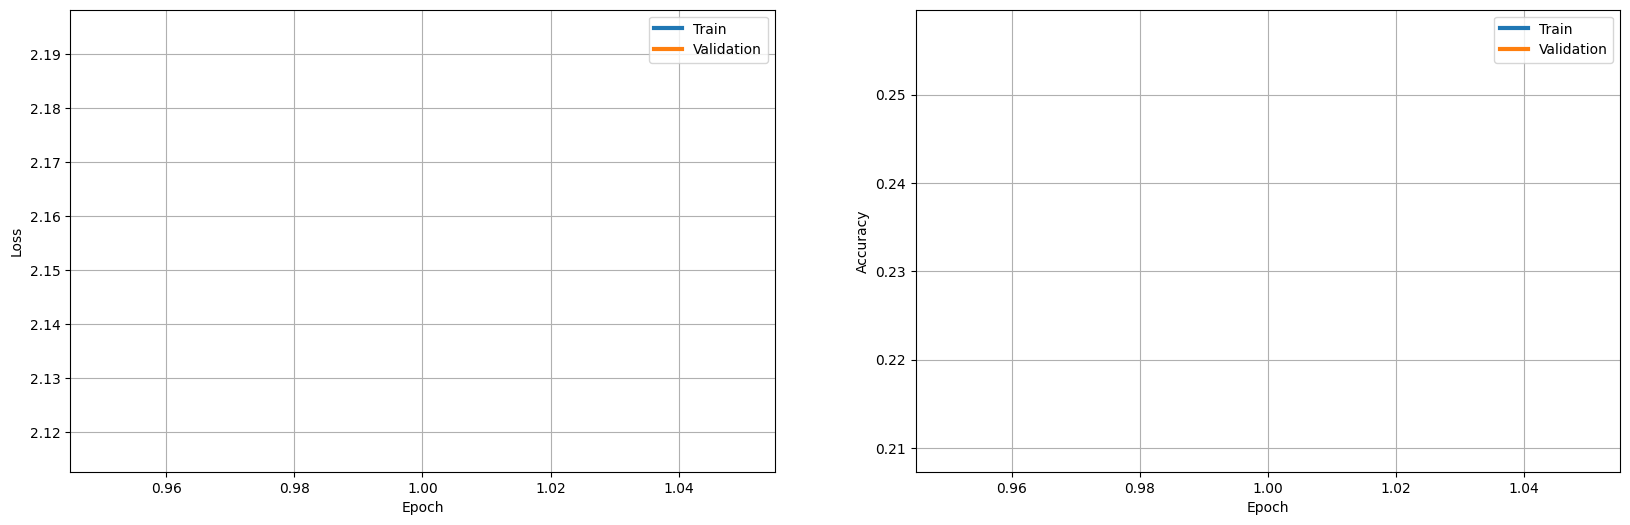

In [ ]:
# Train a basic model?!?!? nah bro
#plot_results(N_EPOCHS, train_losses, train_accs, valid_losses, valid_accs)

In [36]:
# Test model
def model_testing(model, test_iterator, criterion, device, model_name='best_model.pt'):
  # Load best weights
  model.load_state_dict(torch.load(model_name))
  # Evaluate model
  test_loss, test_acc = evaluate(model, test_iterator, criterion, device)
  # Print results
  print(f"Test -- Loss: {test_loss:.3f}, Acc: {test_acc * 100:.2f} %")

In [ ]:
# Test a basic model?!?!? nah bro
#model_testing(model, test_iterator, criterion, device, 'mlp.pt')

Test -- Loss: 2.116, Acc: 26.67 %


###  Confusion matrix and classification report

In [38]:
def predict(model, iterator, device):

  # Evaluation mode
  model.eval()

  labels = []
  pred = []

  with torch.no_grad():
    for (x, y) in iterator:
      x = x.to(device)
      y_pred = model(x)

      # Get label with highest score
      y_prob = F.softmax(y_pred, dim = -1)
      top_pred = y_prob.argmax(1, keepdim=True)

      labels.append(y.cpu())
      pred.append(top_pred.cpu())

  labels = torch.cat(labels, dim=0)
  pred = torch.cat(pred, dim=0)

  return labels, pred


In [39]:
def print_report(model, test_iterator, device):
  labels, pred = predict(model, test_iterator, device)
  print(confusion_matrix(labels, pred))
  print("\n")
  print(classification_report(labels, pred))

In [ ]:
# Print a basic model?!?!? nah bro
#print_report(model, test_iterator, device)

[[526  55   1   5   2  22  73  28 133 155]
 [107 202   4  12  14  24 224  25 108 280]
 [225  49  25   5  24  44 424  64  74  66]
 [130  45  10  18  22 113 409  84  50 119]
 [ 91  41  16   5  32  38 571  72  45  89]
 [129  33  14  23  16 191 374  70  74  76]
 [ 83  43  14  20  15  33 620  55  32  85]
 [118  31   9   9  12  41 318 180  53 229]
 [181  56   0   3   3  55  66  11 329 296]
 [ 99  92   3   5   9  12  86  31 110 553]]


              precision    recall  f1-score   support

           0       0.31      0.53      0.39      1000
           1       0.31      0.20      0.25      1000
           2       0.26      0.03      0.05      1000
           3       0.17      0.02      0.03      1000
           4       0.21      0.03      0.06      1000
           5       0.33      0.19      0.24      1000
           6       0.20      0.62      0.30      1000
           7       0.29      0.18      0.22      1000
           8       0.33      0.33      0.33      1000
           9       0.28   

### Plotting weights to check if a neuron has learned to look for specific patterns in the input.

In [41]:
def normalize_image(image):
  image = torch.clamp(image, min = image.min(), max = image.max())
  image = torch.add(image, -image.min()).div_(image.max() - image.min() + 1e-5)
  return image

Weights shape: torch.Size([100, 3072])


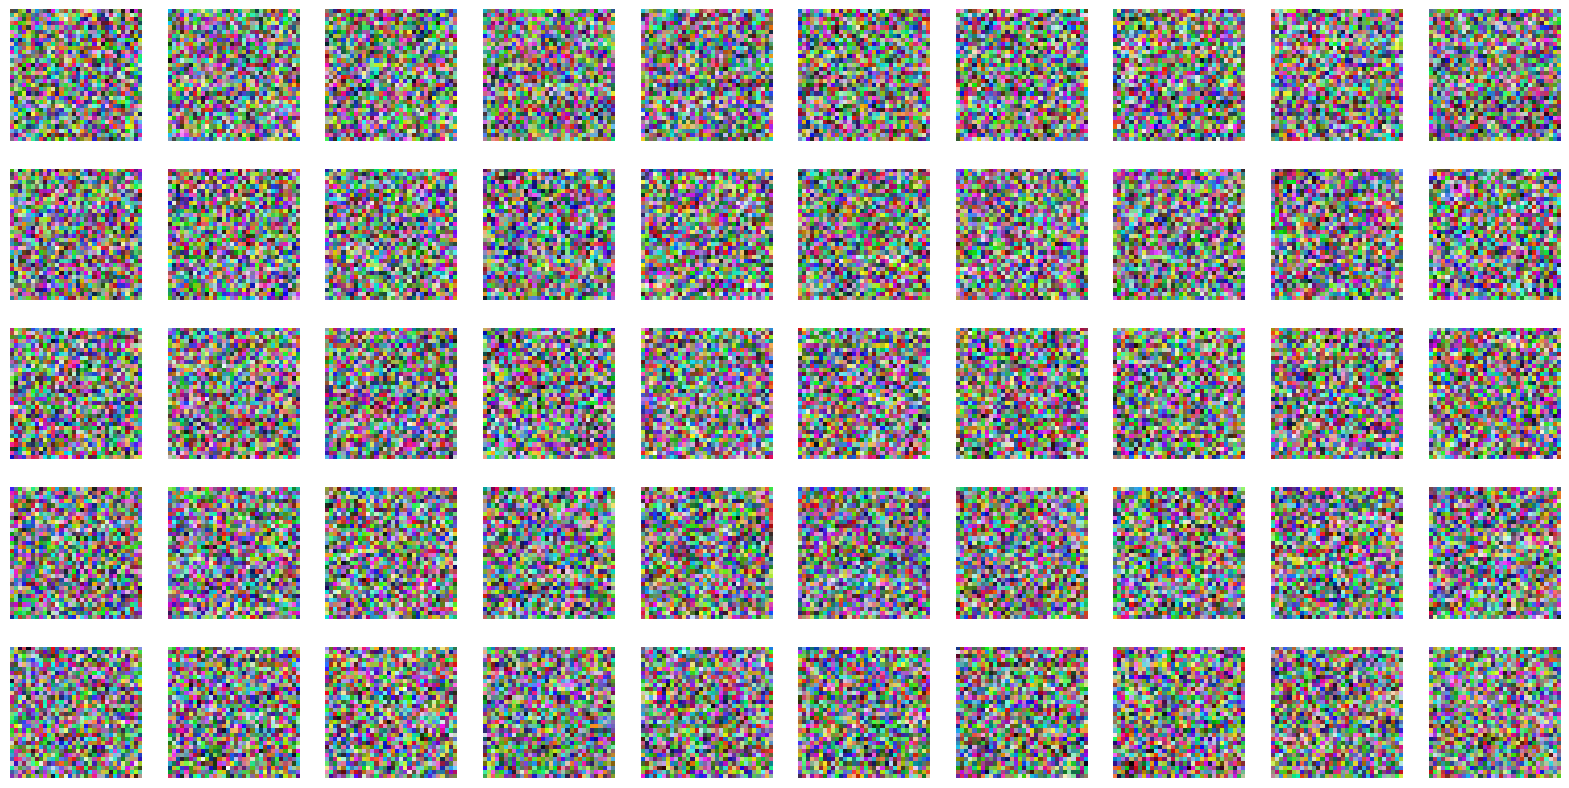

In [ ]:
# Plot weights 
# visualize weights for basic model?!?!? nah bro
"""
weights = model.fc1.weight.data
print(f"Weights shape: {weights.shape}")
plt.figure(figsize=(20, 10))
for i in range(50):
  plt.subplot(5, 10, i+1), plt.imshow(normalize_image(weights[i].view(32,32,3)).cpu().numpy())
  plt.axis('off')
"""

# **Data augmentation**

* Pytorch transformations are available at https://pytorch.org/vision/stable/transforms.html.

In [72]:
# Apply random rotation + horizontal flipping
# Composition of transformations

# COMPOSE IS LIKE TENSORFLOW PREPROCESSING PIPELINES
train_transforms = torchvision.transforms.Compose([
                                                   torchvision.transforms.RandomRotation(15),
                                                   torchvision.transforms.RandomHorizontalFlip(p=0.6),
                                                   # torchvision.transforms.ColorJitter(),
                                                   # torchvision.transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
                                                   # torchvision.transforms.RandomVerticalFlip(),
                                                   torchvision.transforms.ToTensor(),
                                                   torchvision.transforms.Normalize(train_mean, train_std)
])

In [73]:
train_data.dataset.transform = train_transforms

train_iterator = torch.utils.data.DataLoader(train_data,
                                             shuffle=True,
                                             batch_size=BATCH_SIZE)

# Create new model
model = MLP(INPUT_DIM, OUTPUT_DIM)

optimizer = optim.SGD(model.parameters(), lr=5e-3)
model = model.to(device)

In [ ]:
N_EPOCHS = 1
# Train a basic model?!?!? nah bro
#train_losses, train_accs, valid_losses, valid_accs = model_training(N_EPOCHS,model,train_iterator,valid_iterator,optimizer,criterion,device,'mlp_data_aug.pt')


Epoch: 1/1 -- Epoch Time: 16.38 s
---------------------------------
Train -- Loss: 2.163, Acc: 24.05%
Val -- Loss: 2.078, Acc: 28.42%


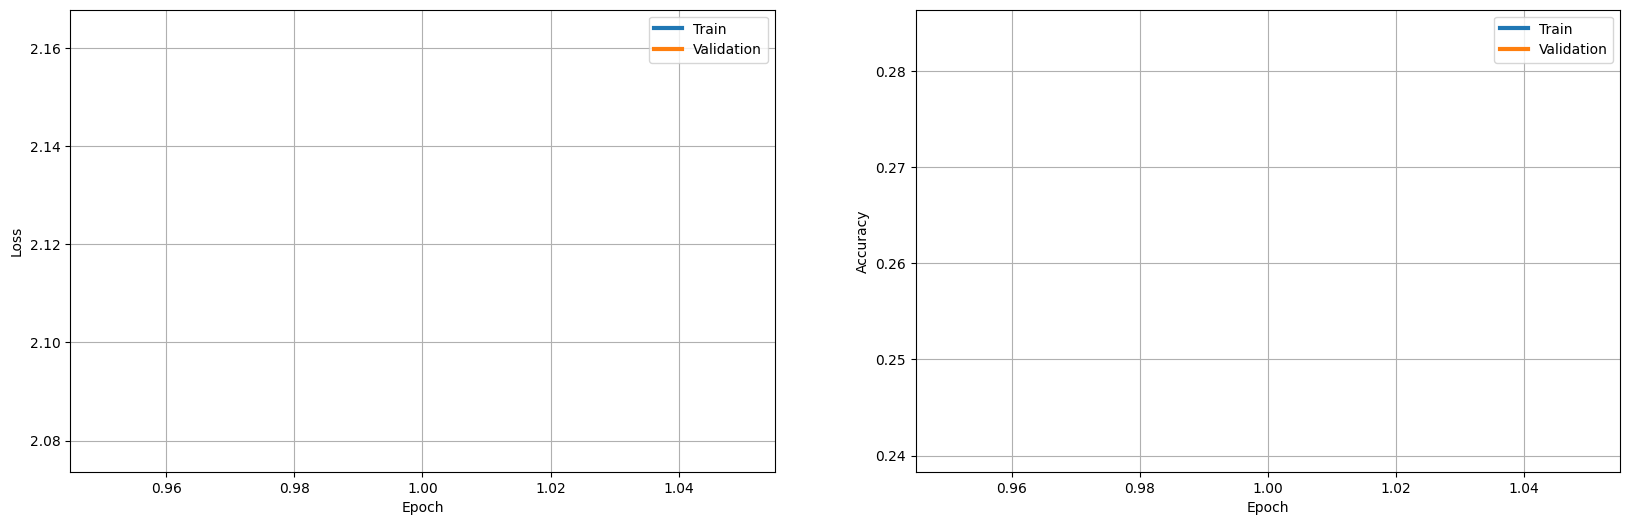

In [ ]:
# Train a basic model?!?!? nah bro
#plot_results(N_EPOCHS, train_losses, train_accs, valid_losses, valid_accs)

In [ ]:
#model_testing(model, test_iterator, criterion, device, 'mlp_data_aug.pt')

Test -- Loss: 2.075, Acc: 28.11 %


In [ ]:
#print_report(model, test_iterator, device)

[[520  63   2   9   6  15  36  19 254  76]
 [121 246   2  13  21  27 157  18 198 197]
 [239  79  21  18  60  71 291  66  79  76]
 [135  81  10  48  31 183 272  55  64 121]
 [100  64  18  22  84  89 419  59  57  88]
 [123  66  16  36  41 268 211  48 100  91]
 [ 80  78   7  25  18  77 552  48  17  98]
 [114  45   9  20  57  95 202 121  95 242]
 [178  49   0   5   9  51  30   4 564 110]
 [113 116   0   6  11  15  74  25 236 404]]


              precision    recall  f1-score   support

           0       0.30      0.52      0.38      1000
           1       0.28      0.25      0.26      1000
           2       0.25      0.02      0.04      1000
           3       0.24      0.05      0.08      1000
           4       0.25      0.08      0.13      1000
           5       0.30      0.27      0.28      1000
           6       0.25      0.55      0.34      1000
           7       0.26      0.12      0.17      1000
           8       0.34      0.56      0.42      1000
           9       0.27   

# **Weights Initialization**

Weights initialization methods are available at https://pytorch.org/docs/stable/nn.init.html


In [49]:
# Define a method for weights initialization
def weights_init(model):
    if isinstance(model, nn.Linear):
        nn.init.uniform_(model.weight.data, -0.02, 0.02) # [zeros_, normal_, xavier_uniform_, xavier_normal_]
        nn.init.constant_(model.bias, 0.01)

In [50]:
model = MLP(INPUT_DIM, OUTPUT_DIM)
optimizer = optim.SGD(model.parameters(), lr=5e-3)
model = model.to(device)

In [51]:
# Apply initialization
model.apply(weights_init)

MLP(
  (fc1): Linear(in_features=3072, out_features=100, bias=True)
  (fc2): Linear(in_features=100, out_features=10, bias=True)
  (sigmoid): Sigmoid()
)

In [52]:
# Weights Initialization + Data Augmentation
N_EPOCHS = 25
#train_losses, train_accs, valid_losses, valid_accs = model_training(N_EPOCHS,model,train_iterator,valid_iterator,optimizer,criterion,device,'mlp_new_weights.pt')


Epoch: 1/25 -- Epoch Time: 16.43 s
---------------------------------
Train -- Loss: 2.276, Acc: 19.95%
Val -- Loss: 2.236, Acc: 23.32%

Epoch: 2/25 -- Epoch Time: 15.35 s
---------------------------------
Train -- Loss: 2.195, Acc: 24.58%
Val -- Loss: 2.148, Acc: 24.92%

Epoch: 3/25 -- Epoch Time: 15.11 s
---------------------------------
Train -- Loss: 2.115, Acc: 26.07%
Val -- Loss: 2.082, Acc: 27.50%

Epoch: 4/25 -- Epoch Time: 14.54 s
---------------------------------
Train -- Loss: 2.056, Acc: 27.40%
Val -- Loss: 2.034, Acc: 28.50%

Epoch: 5/25 -- Epoch Time: 15.50 s
---------------------------------
Train -- Loss: 2.014, Acc: 28.60%
Val -- Loss: 2.001, Acc: 29.20%

Epoch: 6/25 -- Epoch Time: 15.15 s
---------------------------------
Train -- Loss: 1.982, Acc: 29.44%
Val -- Loss: 1.976, Acc: 29.86%

Epoch: 7/25 -- Epoch Time: 15.56 s
---------------------------------
Train -- Loss: 1.959, Acc: 30.19%
Val -- Loss: 1.956, Acc: 30.29%

Epoch: 8/25 -- Epoch Time: 14.45 s
------------

In [53]:
#plot_results(N_EPOCHS, train_losses, train_accs, valid_losses, valid_accs)

In [54]:
#model_testing(model, test_iterator, criterion, device, 'mlp_new_weights.pt')

In [55]:
#print_report(model, test_iterator, device)

Let's create a different architecture using dropout, Adam optimizer and a different linear layers' initialization.

RuntimeError: Error(s) in loading state_dict for MLP:
	Missing key(s) in state_dict: "linear_layers.5.weight", "linear_layers.5.bias", "linear_layers.7.weight", "linear_layers.7.bias". 
	Unexpected key(s) in state_dict: "linear_layers.12.weight", "linear_layers.12.bias", "linear_layers.15.weight", "linear_layers.15.bias", "linear_layers.18.weight", "linear_layers.18.bias", "linear_layers.21.weight", "linear_layers.21.bias", "linear_layers.6.weight", "linear_layers.6.bias". 
	size mismatch for linear_layers.0.weight: copying a param with shape torch.Size([3000, 3072]) from checkpoint, the shape in current model is torch.Size([1500, 3072]).
	size mismatch for linear_layers.0.bias: copying a param with shape torch.Size([3000]) from checkpoint, the shape in current model is torch.Size([1500]).
	size mismatch for linear_layers.3.weight: copying a param with shape torch.Size([1500, 3000]) from checkpoint, the shape in current model is torch.Size([750, 1500]).
	size mismatch for linear_layers

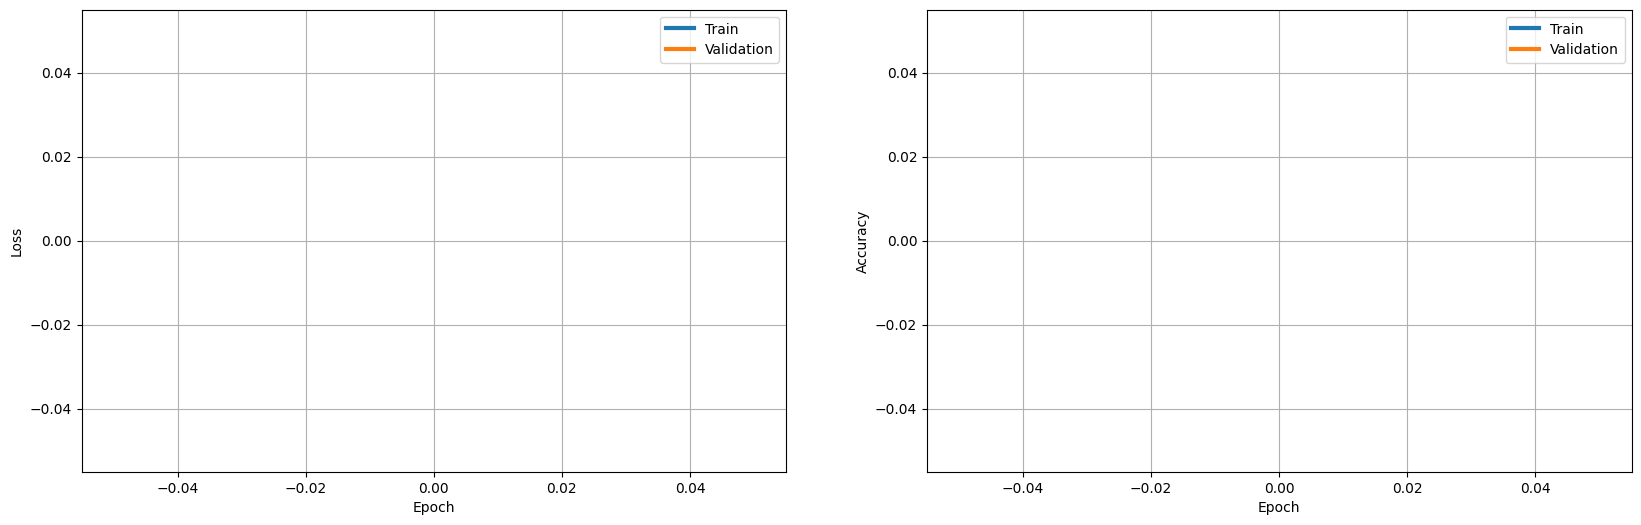

In [56]:
# Previous data augmentation is applied
# MLP architecture:
# [3072] -> [1500] -> ReLU -> Dropout(0.3) -> [750] -> ReLU -> Dropout(0.1) -> [300] -> ReLU -> Dropout(0.2) -> [10]

def weights_init(model):
    if isinstance(model, nn.Linear):
        nn.init.kaiming_normal_(model.weight.data)
        nn.init.constant_(model.bias, 0.01)

class MLP(nn.Module):
  def __init__(self, input_dim, output_dim):
    super().__init__()

    self.linear_layers = nn.Sequential(
        nn.Linear(input_dim, 1500),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(1500, 750),
        nn.ReLU(),
        nn.Linear(750, 300),
        nn.ReLU(),
        nn.Linear(300, 150),
        nn.ReLU(),
        nn.Linear(150, output_dim)
    )

  def forward(self, x):
    batch_size = x.shape[0]
    # Flatten x
    x = x.view(batch_size, -1)
    # Apply linear
    out = self.linear_layers(x)

    return out

model = MLP(INPUT_DIM, OUTPUT_DIM)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
model = model.to(device)


# Apply initialization
model.apply(weights_init)

# Train a basic model?!?!? nah bro
# Weights Initialization + Data Augmentation
N_EPOCHS = 0
train_losses, train_accs, valid_losses, valid_accs = model_training(N_EPOCHS,
                                                                    model,
                                                                    train_iterator,
                                                                    valid_iterator,
                                                                    optimizer,
                                                                    criterion,
                                                                    device,
                                                                    model_name='final_mlp.pt')

plot_results(N_EPOCHS, train_losses, train_accs, valid_losses, valid_accs)
model_testing(model, test_iterator, criterion, device, model_name='final_mlp.pt')
print_report(model, test_iterator, device)

In [ ]:
# Plot weights
# Train a basic model?!?!? nah bro
"""
weights = model.linear_layers[0].weight.data
print(f"Weights shape: {weights.shape}")
plt.figure(figsize=(20, 10))
for i in range(50):
  plt.subplot(5, 10, i+1), plt.imshow(normalize_image(weights[i*10].view(32,32,3)).cpu().numpy())
  plt.axis('off')
"""

AttributeError: 'MLP' object has no attribute 'linear_layers'

# **MLP Contest**

*   [Submit results]()
*   [Ranking Visualization]()

Previous networks do not perform well on CIFAR-10 dataset. Design your own architecture (based on MLPs) and set the corresponding hyper-parameters in order to achieve better performance on the test set. Some parameters to focus on are listed below:

#### *Network's parameters*:

- Number of layers;
- Number of neurons per layer;
- Activation functions;
- Weights initialization;
- Dropout Rate.

#### *Training parameters*:
- Learning rate;
- Number of epochs;
- Optimizer;
- Batch size.

#### *Data*:
- Data augmentation.

You can also use different training techniques (e.g., early stopping, LR schedule) or consider ensemble methods.

## MLP #0 

Here we will try deeper neural networks, dropout, improving preprocessing (augmentation) and other techniques. Also tuning the neural network hyperparameters. The Changes are:

1. Dropout rates are lowered (0.3-0.15) and added to all layers
2. Added WEIGHT DECAY to the optimizer
3. The MLP is wider and longer

Some results are astounding... The network keeps learning although sometimes it get stuck. Also it has higher accuracy scores on validation data than train, this is probably due to the small preprocessing and dropout, which is a great sign!

---
Note: This MLP is long and wide so its probably going to be a nightmare of exploding/vanishing gradients



In [58]:
LEARNING_RATE=1e-5
WEIGHT_DECAY=1e-4
BATCH_SIZE=128
N_EPOCHS=50


Epoch: 1/50 -- Epoch Time: 55.25 s
---------------------------------
Train -- Loss: 2.960, Acc: 11.55%
Val -- Loss: 2.188, Acc: 21.46%

Epoch: 2/50 -- Epoch Time: 52.91 s
---------------------------------
Train -- Loss: 2.398, Acc: 14.29%
Val -- Loss: 2.145, Acc: 25.41%

Epoch: 3/50 -- Epoch Time: 54.59 s
---------------------------------
Train -- Loss: 2.286, Acc: 16.77%
Val -- Loss: 2.075, Acc: 26.95%

Epoch: 4/50 -- Epoch Time: 60.34 s
---------------------------------
Train -- Loss: 2.207, Acc: 19.43%
Val -- Loss: 2.023, Acc: 28.55%

Epoch: 5/50 -- Epoch Time: 56.67 s
---------------------------------
Train -- Loss: 2.151, Acc: 20.91%
Val -- Loss: 1.981, Acc: 29.73%

Epoch: 6/50 -- Epoch Time: 57.36 s
---------------------------------
Train -- Loss: 2.096, Acc: 23.05%
Val -- Loss: 1.942, Acc: 31.74%

Epoch: 7/50 -- Epoch Time: 58.57 s
---------------------------------
Train -- Loss: 2.061, Acc: 24.32%
Val -- Loss: 1.909, Acc: 33.55%

Epoch: 8/50 -- Epoch Time: 57.34 s
------------

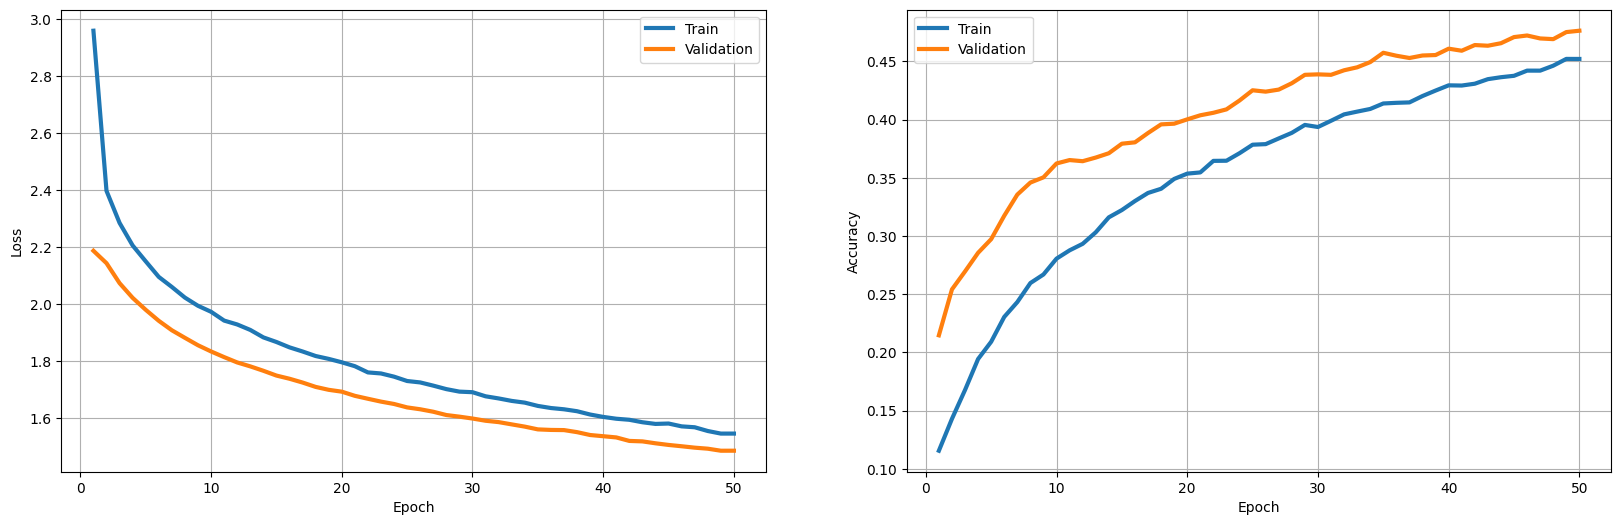

In [59]:
# Previous data augmentation is applied
# MLP architecture:
# [3072] -> [1500] -> ReLU -> Dropout(0.3) -> [750] -> ReLU -> Dropout(0.1) -> [300] -> ReLU -> Dropout(0.2) -> [10]

def weights_init(model):
    if isinstance(model, nn.Linear):
        nn.init.kaiming_normal_(model.weight.data)
        nn.init.constant_(model.bias, 0.01)

class MLP(nn.Module):
  def __init__(self, input_dim, output_dim):
    super().__init__()

    self.linear_layers = nn.Sequential(
        nn.Linear(input_dim, 2000),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(2000, 1500),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(1500, 1000),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(1000, 750),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(750, 500),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(500, 250),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(250, 125),
        nn.ReLU(),
        nn.Dropout(0.15),
        nn.Linear(125, output_dim)
    )

  def forward(self, x):
    batch_size = x.shape[0]
    # Flatten x
    x = x.view(batch_size, -1)
    # Apply linear
    out = self.linear_layers(x)

    return out

model = MLP(INPUT_DIM, OUTPUT_DIM)
# 
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
model = model.to(device)


# Apply initialization
model.apply(weights_init)

# Weights Initialization + Data Augmentation
train_losses, train_accs, valid_losses, valid_accs = model_training(N_EPOCHS,
                                                                    model,
                                                                    train_iterator,
                                                                    valid_iterator,
                                                                    optimizer,
                                                                    criterion,
                                                                    device,
                                                                    model_name='1_big_fat_mlp_relu_dropout.pt')

plot_results(N_EPOCHS, train_losses, train_accs, valid_losses, valid_accs)
model_testing(model, test_iterator, criterion, device, model_name='1_big_fat_mlp_relu_dropout.pt')
print_report(model, test_iterator, device)

Results: 
- Test accuracy of 48.97% 
- Test loss of 1.45

LETS GOOOOO DUDE only 50 epochs for this not bad :)

## MLP #1 

Here we will experiment with preprocessing, making the world intense preprocessing pipeline ever. It has over 14+ preprocessing transformations only of which 12 are enabled. The random and probabilistic nature of this pipeline makes it almost impossible from epoch to epoch to see the same image again and again. Therefore in this approach we will try 3 different things:

- More epochs
- More regularization 
- Make the network a bit longer **9 Layers!!!**
- Crazy probabilistic Preprocessing

So to give the model the ability to generalize we need to ensure 
1) The neural network is big enough 
2) The number of epochs is high > 50 

In the past experiment we noticed that epoch through epoch the network will keep learning (1 epoch/minute more or less) so if we now avoid limiting it to 50 and we ensure regularization measures to avoid overfitting, we can achieve even higher scores. 

The learning rate of 10^-5 seems appropiate to avoid bouncing gradients, we will keep batch size of 128 but upgrade N_EPOCHS=256 (9h approx) :)


In [66]:
LEARNING_RATE=1e-5
WEIGHT_DECAY=1e-4
BATCH_SIZE=128
N_EPOCHS=200

In [70]:
# Apply random rotation + horizontal flipping
# Composition of transformations

# COMPOSE IS LIKE TENSORFLOW PREPROCESSING PIPELINES
train_transforms = torchvision.transforms.Compose([
                                                   #torchvision.transforms.Pad(padding=4, padding_mode='reflect'), 
                                                   #torchvision.transforms.RandomCrop(32), # Crop back to original size 32x32

                                                   torchvision.transforms.RandomRotation(90),

                                                   torchvision.transforms.RandomHorizontalFlip(p=0.6),

                                                   torchvision.transforms.RandomPerspective(distortion_scale=0.2, p=0.25),

                                                   #torchvision.transforms.RandomPosterize(p=0.1, bits=6),

                                                   #torchvision.transforms.RandomEqualize(p=0.05),

                                                   #torchvision.transforms.ColorJitter(),

                                                   #torchvision.transforms.GaussianBlur(kernel_size=4, sigma=(0.1, 2.0)),

                                                   torchvision.transforms.RandomVerticalFlip(p=0.5),

                                                   #torchvision.transforms.RandomErasing(p=0.2, scale=(0.02, 0.2), ratio=(0.3, 3.3)),

                                                   #torchvision.transforms.RandomAffine(degrees=45),

                                                   torchvision.transforms.RandomGrayscale(p=0.1),

                                                   torchvision.transforms.RandomInvert(p=0.3),
                                                                                                      
                                                   torchvision.transforms.ToTensor(),
                                                   torchvision.transforms.Normalize(train_mean, train_std)
                                                ])
train_data.dataset.transform = train_transforms
train_iterator = torch.utils.data.DataLoader(train_data,shuffle=True,batch_size=BATCH_SIZE)


In [71]:
# Previous data augmentation is applied
# MLP architecture:
# [3072] -> [1500] -> ReLU -> Dropout(0.3) -> [750] -> ReLU -> Dropout(0.1) -> [300] -> ReLU -> Dropout(0.2) -> [10]

def weights_init(model):
    if isinstance(model, nn.Linear):
        nn.init.kaiming_normal_(model.weight.data)
        nn.init.constant_(model.bias, 0.01)

class MLP(nn.Module):
  def __init__(self, input_dim, output_dim):
    super().__init__()

    self.linear_layers = nn.Sequential(
        nn.Linear(input_dim, 2000),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(2000, 1500),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(1500, 1250),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(1250, 1000),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(1000, 750),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(750, 500),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(500, 250),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(250, 125),
        nn.ReLU(),
        nn.Dropout(0.25),
        nn.Linear(125, output_dim)
    )

  def forward(self, x):
    batch_size = x.shape[0]
    # Flatten x
    x = x.view(batch_size, -1)
    # Apply linear
    out = self.linear_layers(x)

    return out

model = MLP(INPUT_DIM, OUTPUT_DIM)
# 
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
model = model.to(device)


# Apply initialization
model.apply(weights_init)

# Weights Initialization + Data Augmentation
train_losses, train_accs, valid_losses, valid_accs = model_training(N_EPOCHS,
                                                                    model,
                                                                    train_iterator,
                                                                    valid_iterator,
                                                                    optimizer,
                                                                    criterion,
                                                                    device,
                                                                    model_name='2_fat_mlp_augmented.pt')

plot_results(N_EPOCHS, train_losses, train_accs, valid_losses, valid_accs)
model_testing(model, test_iterator, criterion, device, model_name='2_fat_mlp_augmented.pt')
print_report(model, test_iterator, device)


Epoch: 1/200 -- Epoch Time: 66.63 s
---------------------------------
Train -- Loss: 4.934, Acc: 10.00%
Val -- Loss: 2.298, Acc: 11.80%

Epoch: 2/200 -- Epoch Time: 66.08 s
---------------------------------
Train -- Loss: 2.954, Acc: 10.14%
Val -- Loss: 2.300, Acc: 10.64%

Epoch: 3/200 -- Epoch Time: 69.45 s
---------------------------------
Train -- Loss: 2.633, Acc: 10.26%
Val -- Loss: 2.300, Acc: 10.21%

Epoch: 4/200 -- Epoch Time: 70.59 s
---------------------------------
Train -- Loss: 2.517, Acc: 10.04%
Val -- Loss: 2.301, Acc: 9.84%


KeyboardInterrupt: 

## MLP #2: Residual Network + Layer Normalization

In [75]:
LEARNING_RATE=1e-5
WEIGHT_DECAY=1e-4
BATCH_SIZE=128
N_EPOCHS=200

In [76]:
import torch.nn as nn
import torch.optim as optim

class ResidualBlock(nn.Module):
    """
    A block incorporating a Linear layer, Dropout, skip connection, 
    Layer Normalization, and a CHANGEABLE activation function.
    """
    def __init__(self, input_dim, output_dim, dropout_rate, activation_fn=nn.ReLU):
        super().__init__()
        
        # --- Main Processing Path ---
        self.linear = nn.Linear(input_dim, output_dim)
        self.dropout = nn.Dropout(dropout_rate)
        
        # --- Shortcut Path ---
        if input_dim != output_dim:
            self.shortcut = nn.Linear(input_dim, output_dim)
        else:
            self.shortcut = nn.Identity()

        # --- Normalization and Activation ---
        self.norm = nn.LayerNorm(output_dim) 
        self.activation = activation_fn() 

    def forward(self, x):
        identity = x
        
        # 1. Main Path
        out = self.linear(x)
        out = self.dropout(out)
        
        # 2. Shortcut and Addition (SKIP CONNECTION / RESIDUAL)
        shortcut = self.shortcut(identity)
        out = out + shortcut 
        
        # 3. Post-Addition Normalization and Activation
        out = self.norm(out) 
        out = self.activation(out) 
        return out
    
class Residual_MLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()

        # Initial Layer (3072 -> 2000). Not a residual block yet.
        # This is where we flatten the input.
        self.initial_layer = nn.Sequential(
            nn.Linear(input_dim, 2000),
            nn.ReLU(),
            nn.Dropout(0.4)
        )
        
        # Stack of Residual Blocks
        self.residual_blocks = nn.Sequential(
            # Block 1: 2000 -> 1500 (Dropout 0.3)
            ResidualBlock(2000, 1500, 0.3),
            
            # Block 2: 1500 -> 1250 (Dropout 0.3)
            ResidualBlock(1500, 1250, 0.3),
            
            # Block 3: 1250 -> 1000 (Dropout 0.3)
            ResidualBlock(1250, 1000, 0.3),
            
            # Block 4: 1000 -> 750 (Dropout 0.3)
            ResidualBlock(1000, 750, 0.3),
            
            # Block 5: 750 -> 500 (Dropout 0.3)
            ResidualBlock(750, 500, 0.3),
            
            # Block 6: 500 -> 250 (Dropout 0.3)
            ResidualBlock(500, 250, 0.3),
            
            # Block 7: 250 -> 125 (Dropout 0.25)
            ResidualBlock(250, 125, 0.25)
        )
        
        # Final Classification Layer
        self.output_layer = nn.Linear(125, output_dim)

    def forward(self, x):
        batch_size = x.shape[0]
        # Flatten x (3072 features)
        x = x.view(batch_size, -1)
        
        # Pass through initial layer
        x = self.initial_layer(x)
        
        # Pass through residual stack
        x = self.residual_blocks(x)
        
        # Final classification
        out = self.output_layer(x)
        return out

model = Residual_MLP(INPUT_DIM, OUTPUT_DIM)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
model = model.to(device)


# Apply initialization
model.apply(weights_init)

# Weights Initialization + Data Augmentation
train_losses, train_accs, valid_losses, valid_accs = model_training(N_EPOCHS,
                                                                    model,
                                                                    train_iterator,
                                                                    valid_iterator,
                                                                    optimizer,
                                                                    criterion,
                                                                    device,
                                                                    model_name='3_fat_residual_mlp.pt')

plot_results(N_EPOCHS, train_losses, train_accs, valid_losses, valid_accs)
model_testing(model, test_iterator, criterion, device, model_name='3_fat_residual_mlp.pt')
print_report(model, test_iterator, device)


Epoch: 1/200 -- Epoch Time: 73.04 s
---------------------------------
Train -- Loss: 2.339, Acc: 13.57%
Val -- Loss: 2.069, Acc: 24.79%

Epoch: 2/200 -- Epoch Time: 73.83 s
---------------------------------
Train -- Loss: 2.136, Acc: 21.26%
Val -- Loss: 1.993, Acc: 28.67%

Epoch: 3/200 -- Epoch Time: 72.69 s
---------------------------------
Train -- Loss: 2.023, Acc: 25.24%
Val -- Loss: 1.937, Acc: 32.19%

Epoch: 4/200 -- Epoch Time: 72.76 s
---------------------------------
Train -- Loss: 1.949, Acc: 28.65%
Val -- Loss: 1.890, Acc: 34.30%

Epoch: 5/200 -- Epoch Time: 69.27 s
---------------------------------
Train -- Loss: 1.894, Acc: 30.73%
Val -- Loss: 1.844, Acc: 36.17%

Epoch: 6/200 -- Epoch Time: 73.59 s
---------------------------------
Train -- Loss: 1.844, Acc: 32.78%
Val -- Loss: 1.813, Acc: 37.21%

Epoch: 7/200 -- Epoch Time: 73.43 s
---------------------------------
Train -- Loss: 1.806, Acc: 34.59%
Val -- Loss: 1.805, Acc: 37.64%

Epoch: 8/200 -- Epoch Time: 70.16 s
----

KeyboardInterrupt: 

### MLP #3 : Smaller Residual Network

In [ ]:
LEARNING_RATE=1e-4
WEIGHT_DECAY=1e-4
BATCH_SIZE=256
N_EPOCHS=200

In [81]:
import torch.nn as nn
import torch.optim as optim

class ResidualBlock(nn.Module):
    """
    A block incorporating a Linear layer, Dropout, skip connection, 
    Layer Normalization, and a CHANGEABLE activation function.
    """
    def __init__(self, input_dim, output_dim, dropout_rate, activation_fn=nn.ReLU):
        super().__init__()
        
        # --- Main Processing Path ---
        self.linear = nn.Linear(input_dim, output_dim)
        self.dropout = nn.Dropout(dropout_rate)
        
        # --- Shortcut Path ---
        if input_dim != output_dim:
            self.shortcut = nn.Linear(input_dim, output_dim)
        else:
            self.shortcut = nn.Identity()

        # --- Normalization and Activation ---
        self.norm = nn.LayerNorm(output_dim) 
        self.activation = activation_fn() 

    def forward(self, x):
        identity = x
        
        # 1. Main Path
        out = self.linear(x)
        out = self.dropout(out)
        
        # 2. Shortcut and Addition (SKIP CONNECTION / RESIDUAL)
        shortcut = self.shortcut(identity)
        out = out + shortcut 
        
        # 3. Post-Addition Normalization and Activation
        out = self.norm(out) 
        out = self.activation(out) 
        return out
    
class Residual_MLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()

        # Initial Layer (3072 -> 1500). Not a residual block yet.
        # This is where we flatten the input.
        self.initial_layer = nn.Sequential(
            nn.Linear(input_dim, 1500),
            nn.ReLU(),
            nn.Dropout(0.5)
        )
        # Stack of Residual Blocks
        self.residual_blocks = nn.Sequential(            
            ResidualBlock(1500, 750, 0.1),
            ResidualBlock(750, 500, 0.1),  
            ResidualBlock(500, 300, 0.1),            
            ResidualBlock(300, 150, 0.1),
        )
        # Final Classification Layer
        self.output_layer = nn.Linear(150, output_dim)

    def forward(self, x):
        batch_size = x.shape[0]
        # Flatten x (3072 features)
        x = x.view(batch_size, -1)
        
        # Pass through initial layer
        x = self.initial_layer(x)
        
        # Pass through residual stack
        x = self.residual_blocks(x)
        
        # Final classification
        out = self.output_layer(x)
        return out

model = Residual_MLP(INPUT_DIM, OUTPUT_DIM)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
model = model.to(device)


# Apply initialization
model.apply(weights_init)

# Weights Initialization + Data Augmentation
train_losses, train_accs, valid_losses, valid_accs = model_training(N_EPOCHS,
                                                                    model,
                                                                    train_iterator,
                                                                    valid_iterator,
                                                                    optimizer,
                                                                    criterion,
                                                                    device,
                                                                    model_name='4_skinny_residual_mlp.pt')

plot_results(N_EPOCHS, train_losses, train_accs, valid_losses, valid_accs)
model_testing(model, test_iterator, criterion, device, model_name='4_skinny_residual_mlp.pt')
print_report(model, test_iterator, device)


Epoch: 1/200 -- Epoch Time: 45.24 s
---------------------------------
Train -- Loss: 2.182, Acc: 20.40%
Val -- Loss: 1.952, Acc: 30.12%

Epoch: 2/200 -- Epoch Time: 44.93 s
---------------------------------
Train -- Loss: 1.985, Acc: 27.80%
Val -- Loss: 1.881, Acc: 34.08%

Epoch: 3/200 -- Epoch Time: 43.38 s
---------------------------------
Train -- Loss: 1.906, Acc: 31.22%
Val -- Loss: 1.822, Acc: 36.13%

Epoch: 4/200 -- Epoch Time: 46.75 s
---------------------------------
Train -- Loss: 1.846, Acc: 33.70%
Val -- Loss: 1.786, Acc: 37.46%

Epoch: 5/200 -- Epoch Time: 48.22 s
---------------------------------
Train -- Loss: 1.804, Acc: 34.98%
Val -- Loss: 1.758, Acc: 38.67%


KeyboardInterrupt: 

## MLP #4 Feature Attention?

In [ ]:
LEARNING_RATE=1e-5
WEIGHT_DECAY=1e-4
BATCH_SIZE=256
N_EPOCHS=200

In [ ]:
class FeatureAttentionBlock(nn.Module):
    """
    Applies Squeeze-and-Excitation style attention across the feature dimension.
    """
    def __init__(self, channel_dim, reduction_ratio=8):
        super().__init__()
        
        # 1. Squeeze: Global Average Pooling (Done implicitly by mean)
        # 2. Excitation: Bottleneck MLP to generate weights
        self.se_module = nn.Sequential(
            # First linear layer reduces the dimension (bottleneck)
            nn.Linear(channel_dim, channel_dim // reduction_ratio, bias=False),
            nn.ReLU(),
            # Second linear layer expands back to the original dimension
            nn.Linear(channel_dim // reduction_ratio, channel_dim, bias=False),
            nn.Sigmoid() # Weights are bounded between 0 and 1
        )

    def forward(self, x):
        # x shape is (batch_size, channel_dim)
        
        # 1. Squeeze (Global Average Pooling): Calculate the mean across the channels for each sample.
        # This is equivalent to nn.AdaptiveAvgPool1d(1) for a (B, C) tensor.
        weights = x.mean(dim=1, keepdim=True)
        
        # 2. Excitation: Pass through the bottleneck MLP to get attention scores.
        weights = self.se_module(weights)
        
        # 3. Scale: Element-wise multiplication of the input features by the learned weights.
        return x * weights.expand_as(x)

In [ ]:
class Residual_MLP_Attended(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()        
        initial_dim = 1500
        self.initial_layer = nn.Sequential(
            nn.Linear(input_dim, initial_dim),
            nn.ReLU(),
            nn.Dropout(0.5)
        )
        self.feature_attention = FeatureAttentionBlock(channel_dim=initial_dim, reduction_ratio=16) 
        # Using reduction_ratio=16 for a smaller, faster bottleneck

        # Stack of Residual Blocks starts from the attended features (1500 dim)
        self.residual_blocks = nn.Sequential(            
            ResidualBlock(initial_dim, 750, 0.1), # Starts with 1500
            ResidualBlock(750, 500, 0.1),  
            ResidualBlock(500, 300, 0.1),            
            ResidualBlock(300, 150, 0.1),
        )
        
        self.output_layer = nn.Linear(150, output_dim)

    def forward(self, x):
        batch_size = x.shape[0]
        x = x.view(batch_size, -1)
        
        # 1. Pass through initial layer
        x = self.initial_layer(x)
        
        # 2. Apply Feature Attention
        x = self.feature_attention(x) 
        
        # 3. Pass through residual stack
        x = self.residual_blocks(x)
        
        # 4. Final classification
        out = self.output_layer(x)
        return out
    

model = Residual_MLP(INPUT_DIM, OUTPUT_DIM)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
model = model.to(device)


# Apply initialization
model.apply(weights_init)

# Weights Initialization + Data Augmentation
train_losses, train_accs, valid_losses, valid_accs = model_training(N_EPOCHS,
                                                                    model,
                                                                    train_iterator,
                                                                    valid_iterator,
                                                                    optimizer,
                                                                    criterion,
                                                                    device,
                                                                    model_name='4_skinny_residual_mlp.pt')

plot_results(N_EPOCHS, train_losses, train_accs, valid_losses, valid_accs)
model_testing(model, test_iterator, criterion, device, model_name='4_skinny_residual_mlp.pt')
print_report(model, test_iterator, device)